In [ ]:
! pip install transformers datasets evaluate accelerate


reference:
https://huggingface.co/docs/transformers/model_doc/roberta#transformers.RobertaForSequenceClassification

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
train = pd.read_csv('/content/gdrive/MyDrive/DSSI/NER Data/train (1).csv')
val = pd.read_csv('/content/gdrive/MyDrive/DSSI/NER Data/validation.csv')
test = pd.read_csv('/content/gdrive/MyDrive/DSSI/NER Data/test (2).csv')
mi_mn_df = pd.read_csv('/content/gdrive/MyDrive/DSSI/NER Data/mi_mn_annotated.csv')

Mounted at /content/gdrive


In [ ]:
from transformers import AutoTokenizer, DistilBertForSequenceClassification
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Candidate' or input_label == 'Individual':
        return 1
    else:
        return 0

# encode transactor_type as numeric labels
mi_mn_df['transactor_type'] = np.vectorize(convert_bool)(mi_mn_df['transactor_type'])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
mi_mn_df.rename(columns={"merged_full_name": "full_name", "transactor_type":"label"}, inplace= True )

mi_mn_df

,Unnamed: 0.1,Unnamed: 0,full_name,label
0,0,1667,butzel long pac butzel long political action c...,0
1,1,1668,retired detroit police/fire assn pac retired d...,0
2,2,1669,committee to elect gene haymaker committee to ...,0
3,3,1670,jack coleman for state representativ jack cole...,0
4,4,1671,tuscola county republican party tuscola county...,0
...,...,...,...,...
76699,74545,941633,young progressive majority mn,0
76700,74546,944391,"kaiser, jamie senate committee",0
76701,74547,945886,"cragg, daniel dist court committee",0
76702,74548,948410,"anderson, darrin house committee",0


In [ ]:

def preprocess_function(examples):
    # Tokenize the full_name
    tokenized_inputs = tokenizer(examples["full_name"], truncation=True, padding=True)
    return tokenized_inputs


In [ ]:
from datasets import Dataset

# Convert pandas DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(val)
test_dataset = Dataset.from_pandas(test)
mi_mn_dataset = Dataset.from_pandas(mi_mn_df)
X_mi_mn = mi_mn_df['full_name'].copy()
y_mi_mn = mi_mn_df['label']
# X_mi_mn = Dataset.from_pandas(mi_mn_df['full_name'])


# Binary Classification Individual and Candidate = 0 else 1

# Define label2id and id2label mappings
label2id = {'0': 0, '1': 1,}
id2label = {0: '0', 1: '1'}

# Apply the preprocess_function to the dataset
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)
tokenized_mi_mn = mi_mn_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/114945 [00:00<?, ? examples/s]

Map:   0%|          | 0/15326 [00:00<?, ? examples/s]

Map:   0%|          | 0/38315 [00:00<?, ? examples/s]

Map:   0%|          | 0/76704 [00:00<?, ? examples/s]

In [ ]:
tokenized_mi_mn

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'full_name', 'label', 'input_ids', 'attention_mask'],
    num_rows: 76704
})

In [ ]:
# It’s more efficient to dynamically pad the sentences to the longest length in a batch during collation,
# instead of padding the whole dataset to the maximum length.

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    print(":)")
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='binary'),
        'recall': recall_score(labels, preds, average='binary'),
        'f1': f1_score(labels, preds, average='binary'),
    }
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id)
training_args = TrainingArguments(
    output_dir="/content/gdrive/MyDrive/DSSI/NER Data(my_awesome_model)",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    push_to_hub=False,
    metric_for_best_model="f1",
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


/tmp/ipython-input-19-1103770030.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.191700,0.181497,0.939188,0.901628,0.985610,0.941750
2,0.174300,0.164874,0.941863,0.902395,0.990581,0.944434
3,0.154500,0.151627,0.945061,0.907989,0.990188,0.947309


:)
:)
:)


TrainOutput(global_step=10779, training_loss=0.18118322478429827, metrics={'train_runtime': 1260.9643, 'train_samples_per_second': 273.469, 'train_steps_per_second': 8.548, 'total_flos': 3245393571310476.0, 'train_loss': 0.18118322478429827, 'epoch': 3.0})

In [ ]:
tokenized_mi_mn

In [ ]:
trainer.evaluate(tokenized_test)


:)


{'eval_loss': 0.20336008071899414,
 'eval_accuracy': 0.9384053242855278,
 'eval_precision': 0.9062681369704004,
 'eval_recall': 0.9779749478079331,
 'eval_f1': 0.9407571041269204,
 'eval_runtime': 37.7211,
 'eval_samples_per_second': 1015.744,
 'eval_steps_per_second': 126.985,
 'epoch': 3.0}

In [ ]:
trainer.evaluate(tokenized_mi_mn)

:)


{'eval_loss': 2.474508047103882,
 'eval_accuracy': 0.22479922820191905,
 'eval_precision': 0.9973354864755752,
 'eval_recall': 0.1720813597102257,
 'eval_f1': 0.29351868353828786,
 'eval_runtime': 84.9865,
 'eval_samples_per_second': 902.544,
 'eval_steps_per_second': 112.818,
 'epoch': 3.0}

In [ ]:
y_test = test['label']

In [ ]:
from transformers import DistilBertForSequenceClassification
model_save_path = DistilBertForSequenceClassification.from_pretrained("/content/gdrive/MyDrive/DSSI/NER Data(my_awesome_model)/checkpoint-10779")

In [ ]:
trainer = Trainer(model = model_save_path)
test_results = trainer.predict(tokenized_test)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
test_results.predictions

array([[ 3.3305652, -3.9473991],
       [-3.1315608,  2.8095946],
       [ 3.305991 , -3.921926 ],
       ...,
       [-2.7872221,  2.488889 ],
       [-1.0018417,  0.9518671],
       [ 3.8910778, -4.5102725]], dtype=float32)

In [ ]:
import numpy as np
predicted_classes = np.argmax(test_results.predictions, axis=-1)
print (predicted_classes)

[0 1 0 ... 1 1 0]


In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     19155
           1       0.91      0.98      0.94     19160

    accuracy                           0.94     38315
   macro avg       0.94      0.94      0.94     38315
weighted avg       0.94      0.94      0.94     38315



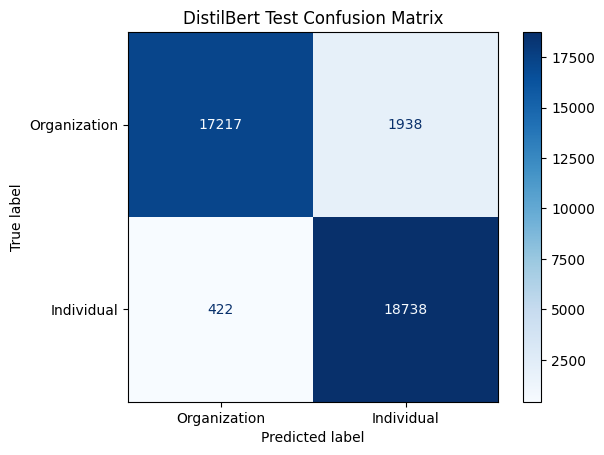

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix
cm = confusion_matrix(y_test, predicted_classes, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("DistilBert Test Confusion Matrix")
plt.savefig("DistilBert Test set.png", transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
trainer = Trainer(model = model_save_path)
test_results = trainer.predict(tokenized_mi_mn)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
test_results.predictions

array([[ 3.2691483, -3.7716036],
       [ 3.9213867, -4.599264 ],
       [ 2.1633344, -2.6914027],
       ...,
       [ 3.105298 , -3.7428315],
       [ 3.2417886, -3.7872763],
       [ 3.5986264, -4.1918573]], dtype=float32)

In [ ]:
import numpy as np
predicted_classes = np.argmax(test_results.predictions, axis=-1)
print (predicted_classes)

[0 0 0 ... 0 0 0]


In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(classification_report(y_mi_mn, predicted_classes))

              precision    recall  f1-score   support

           0       0.08      0.99      0.14      4924
           1       1.00      0.17      0.29     71780

    accuracy                           0.22     76704
   macro avg       0.54      0.58      0.22     76704
weighted avg       0.94      0.22      0.28     76704



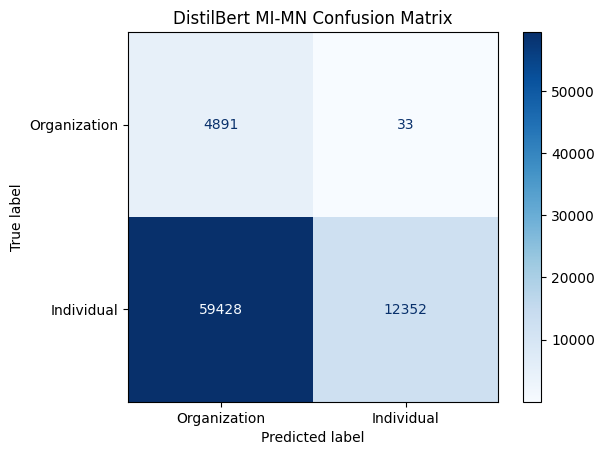

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix
cm = confusion_matrix(y_mi_mn, predicted_classes, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("DistilBert MI-MN Confusion Matrix")
plt.savefig("DistilBert MI-MN set.png", transparent=True, bbox_inches='tight')
plt.show()